<a href="https://colab.research.google.com/github/Knchna/ICT_AI-ML/blob/main/Case_Study_4_Jul_14_Adult_TensorFlow_vs_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
'''
1. Import Libraries

2. Load Dataset

3. Data Overview
   • Shape
   • Head/Tail
   • Info()
   • Describe()
   • Unique values
   • Drop unnecessary columns (e.g., fnlwgt, education)
   • Correct data types, handle impossible values etc.

4. Divide Features by Data Type
   • Numerical columns
       - Continuous
       - Discrete (optional)
   • Categorical columns
       - Nominal
       - Ordinal (optional)

5. Data Cleaning
    ↓
    Duplicate Values
      • Drop duplicate rows
    ↓
    Outlier Detection & Analysis
      • Boxplots => Univariate EDA
      • Histograms => Univariate EDA
      • IQR - if required to view the outlier rows
      • Treatment:
        - Continuous numerical columns only
        - Skip categorical columns
        - Usually skip discrete integer columns unless they have many values
    ↓
    Missing Values
      • Histograms/KDE => Univariate EDA
      • NaN Imputation
    ↓
    Drop Columns with too many missing values

6. Bivariate Analysis
    ↓
    Correlation Matrix
    Scatter Plots
    Mutual Information
    Numerical vs Target
    Categorical vs Target

7. Feature Selection

8. Feature Engineering (if required)

9. Separate X and y

10. Train-Test Split

11. Encoding
    • Fit encoder on training data (or use get_dummies before split if appropriate)
    • Transform test data

12. Scaling
    • fit_transform(X_train)
    • transform(X_test)
'''

'\n1. Import Libraries\n\n2. Load Dataset\n\n3. Data Overview\n   • Shape\n   • Head/Tail\n   • Info()\n   • Describe()\n   • Unique values\n   • Drop unnecessary columns (e.g., fnlwgt, education)\n   • Correct data types, handle impossible values etc.\n\n4. Divide Features by Data Type\n   • Numerical columns\n       - Continuous\n       - Discrete (optional)\n   • Categorical columns\n       - Nominal\n       - Ordinal (optional)\n\n5. Data Cleaning\n    ↓\n    Duplicate Values\n      • Drop duplicate rows\n    ↓\n    Outlier Detection & Analysis\n      • Boxplots => Univariate EDA\n      • Histograms => Univariate EDA\n      • IQR - if required to view the outlier rows\n      • Treatment:\n        - Continuous numerical columns only\n        - Skip categorical columns\n        - Usually skip discrete integer columns unless they have many values\n    ↓\n    Missing Values\n      • Histograms/KDE => Univariate EDA\n      • NaN Imputation\n    ↓    \n    Drop Columns with too many miss

# Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

import tensorflow as tf

import torch
import torch.nn as nn
import torch.optim as optim

import time

# Reading Dataset

In [3]:
filepath = "/content/drive/MyDrive/ICT_AIML Class/Datasets/adult_dataset.csv"

In [4]:
df_adult = pd.read_csv(filepath)
df_adult.head(20)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K
5,37.0,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40.0,United-States,<=50K
6,49.0,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16.0,Jamaica,<=50K
7,52.0,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45.0,United-States,>50K
8,31.0,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50.0,United-States,>50K
9,42.0,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40.0,United-States,>50K


# Data Overview

In [5]:
df_adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [6]:
# Inference:
  # Missing values present

In [7]:
df_adult.shape

(48842, 15)

In [8]:
# Descriptive stats

df_adult.describe(include = "all")

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
count,46400.000000,45480,4.884200e+04,48842,48842.000000,48842,45485,48842,48842,48842,48842.000000,48842.000000,46400.000000,46137,48842
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,4
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,32220,NaN,15784,NaN,22379,5854,19716,41762,32650,NaN,NaN,NaN,41622,24720
mean,38.679116,NaN,1.896641e+05,NaN,10.078089,NaN,NaN,NaN,NaN,NaN,1079.067626,87.502314,40.448599,NaN,NaN
std,13.952954,NaN,1.056040e+05,NaN,2.570973,NaN,NaN,NaN,NaN,NaN,7452.019058,403.004552,12.646992,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.175505e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.781445e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.376420e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


In [9]:
df_adult.columns.tolist()

['age',
 'workclass',
 'fnlwgt',
 'education',
 'education-num',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'native-country',
 'income']

In [10]:
# Displaying unique values and it's count for columns that are possibly discrete

for column in df_adult.columns.tolist():
  if df_adult[column].nunique() < 10000:
    print(f"'{column}': \n")
    print(f" No of unique values is: {df_adult[column].nunique()}")
    print(f" Unique values are: {df_adult[column].value_counts()}")
    print("*******************************************************")

'age': 

 No of unique values is: 82
 Unique values are: age
33.0     1289
36.0     1289
35.0     1276
23.0     1258
31.0     1245
         ... 
225.0       1
86.0        1
140.0       1
100.0       1
210.0       1
Name: count, Length: 82, dtype: int64
*******************************************************
'workclass': 

 No of unique values is: 9
 Unique values are: workclass
Private             32220
Self-emp-not-inc     3649
Local-gov            2973
State-gov            1877
?                    1763
Self-emp-inc         1625
Federal-gov          1346
Without-pay            18
Never-worked            9
Name: count, dtype: int64
*******************************************************
'education': 

 No of unique values is: 16
 Unique values are: education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th       

#### Details of possibly discrete columns - cat & num

In [11]:
# Inference -
  # age:
      # few unrealistic values (e.g., 140, 210, 225) -  Verify as they may represent data entry errors.
      # Continous Numerical

  # workclass
      # Contains 9 categories, including "?" which represents missing values
      # Replace "?" with NaN before missing value imputation.
      # Nominal categorical

  # education
      # Contains 16 education levels
      # Nominal categorical

  # education-num
      # numerical representation of 'education' - because both columns have same value_counts()
      # Ordinal categorical, already encoded as int

  # marital-status
      # Contains 7 categories with a few rare classes
      # Nominal Categorical

  # occupation
      # Contains 15 occupation categories including "?" - convert to NaN
      # Nominal Categorical

  # relationship
      # Contains 6 relationship categories.
      # Nominal Categorical

  # race
      # Contains 5 categories with noticeable class imbalance - 'White' dominate with 40k rows
      # Nominal Categorical

  # sex
      # Binary Categorical  - (Male, Female)
      # Moderately imbalanced but expected

  # capital-gain
      # Highly zero-inflated => majority of observations are 0 -> genuine
      # Strong positive skew with a few large values- could be genuine values in finance, in yearly profit

  # capital-loss
      # Similar to capital-gain, with most values equal to 0 -> genuine
      # Strong positive skew with a few large values- could be genuine values in finance, in yearly loss

  # hours-per-week
      # Most individuals work 40 hours/week.
      # Contains unrealistic values (e.g., 250 hours/week) that require investigation.
      # Continuous Numerical?

  # native-country
      # Majority from 'United-States' with ~ 40k rows. But there are 42 classes, including several very rare categories
      # Includes "?" as missing values - replace with NaN
      # Nominal Categorical

  # income (Target)
      # Appears as four labels due to periods(full-stops) => <=50K. and >50K.
      # Standardize these 4 labels into 2 classes before encoding.
      # Binary Categorical Column

#### Dropping Redundant Cols

In [12]:
# 'fnlwgt' => doesn't contribute to target, thus dropped
# 'education' and 'education-num' are duplicate cols

df_adult = df_adult.drop(columns = ['fnlwgt','education'], axis = 1)

In [13]:
# after dropping cols
df_adult.shape

(48842, 13)

#### Replacing "?" with NaN, Correcting target column class labels

In [14]:
df_adult = df_adult.replace("?", np.nan)

In [15]:
df_adult["income"] = df_adult["income"].str.replace(".", "", regex=False)

In [16]:
# after corrections
for column in df_adult.columns.tolist():
  if df_adult[column].nunique() < 10000:
    print(f"'{column}': \n")
    print(f" No of unique values is: {df_adult[column].nunique()}")
    print(f" Unique values are: {df_adult[column].value_counts()}")
    print("*******************************************************")

'age': 

 No of unique values is: 82
 Unique values are: age
33.0     1289
36.0     1289
35.0     1276
23.0     1258
31.0     1245
         ... 
225.0       1
86.0        1
140.0       1
100.0       1
210.0       1
Name: count, Length: 82, dtype: int64
*******************************************************
'workclass': 

 No of unique values is: 8
 Unique values are: workclass
Private             32220
Self-emp-not-inc     3649
Local-gov            2973
State-gov            1877
Self-emp-inc         1625
Federal-gov          1346
Without-pay            18
Never-worked            9
Name: count, dtype: int64
*******************************************************
'education-num': 

 No of unique values is: 16
 Unique values are: education-num
9     15784
10    10878
13     8025
14     2657
11     2061
7      1812
12     1601
6      1389
4       955
15      834
5       756
8       657
16      594
3       509
2       247
1        83
Name: count, dtype: int64
******************************

# Dividing into Num and Cat Cols

In [17]:
continuous_cols = [
    'age',
    'capital-gain',
    'capital-loss',
    'hours-per-week'
]

discrete_cols = [
    'education-num'               # levels of education as int
]

nominal_cols = [
    'workclass',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'native-country'
]

binary_cols = ['sex', 'income']

target_col = 'income'

# Data Cleaning

## Duplicates

In [18]:
df_adult.duplicated().sum()

np.int64(4838)

In [19]:
df_adult = df_adult.drop_duplicates()

In [20]:
# after dropping
df_adult.shape

(44004, 13)

## Outliers Handling

In [21]:
df_adult[continuous_cols].describe()

,age,capital-gain,capital-loss,hours-per-week
count,41845.000000,44004.000000,44004.000000,41662.000000
mean,39.324173,1189.747705,96.459640,40.625390
std,14.010728,7824.395176,422.088736,13.042381
min,17.000000,0.000000,0.000000,1.000000
25%,28.000000,0.000000,0.000000,40.000000
50%,38.000000,0.000000,0.000000,40.000000
75%,48.000000,0.000000,0.000000,45.000000
max,255.000000,99999.000000,4356.000000,250.000000


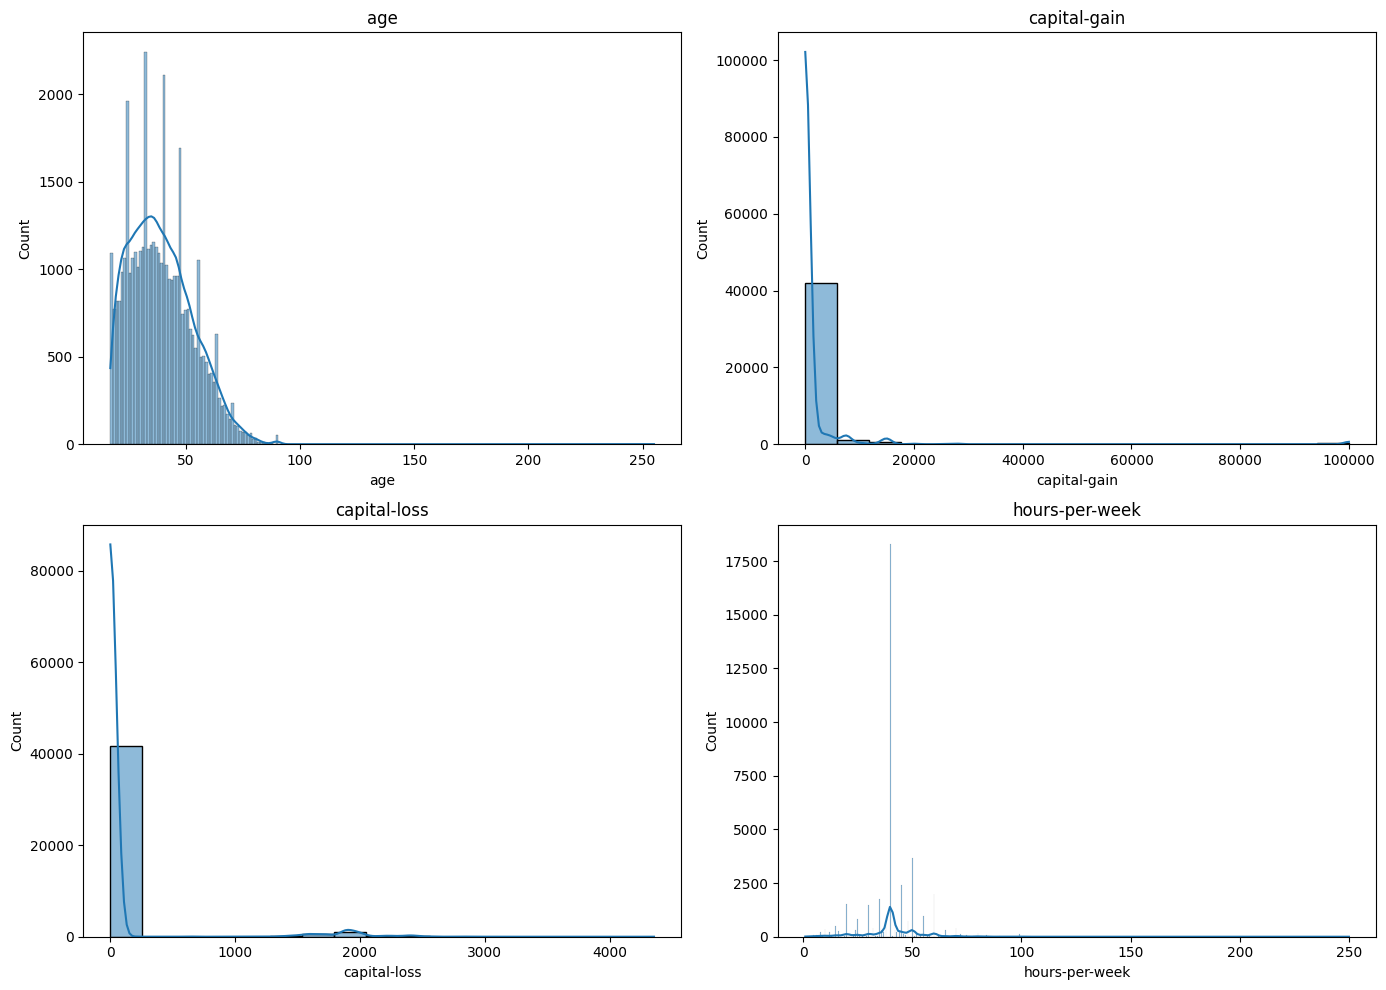

In [22]:
plt.figure(figsize = (14, 10))
i = 1
for column in continuous_cols:
  plt.subplot(2, 2, i)
  sns.histplot(df_adult[column], kde=True)
  plt.title(column)
  i += 1
plt.tight_layout()
plt.show()

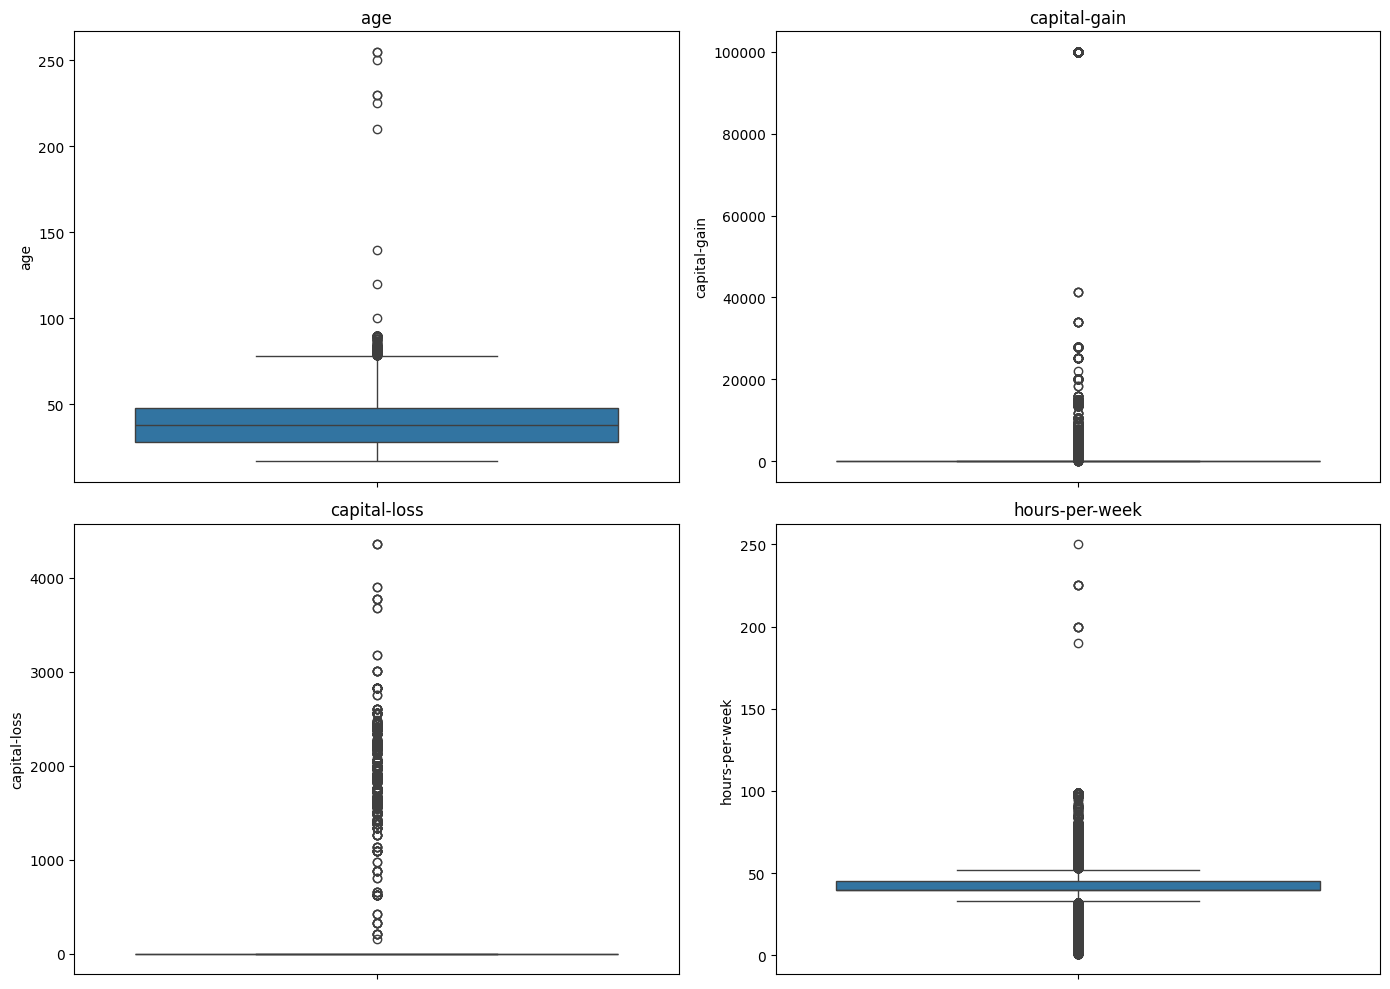

In [23]:
plt.figure(figsize = (14, 10))
i = 1
for column in continuous_cols:
  plt.subplot(2, 2, i)
  sns.boxplot(df_adult[column])
  plt.title(column)
  i += 1
plt.tight_layout()
plt.show()

In [24]:
# Inference:
  # 'age' and 'hours-per-week' has impossible upper values,
  # 'capital-gain' and 'capital-loss' has genuine values in finance - kept as is

In [25]:
# Checing the outliers and upper_bound of 'age' with IQR

Q1 = df_adult['age'].quantile(0.25)
Q3 = df_adult['age'].quantile(0.75)

IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"Upper Bound of Age is: {upper_bound}")

Upper Bound of Age is: 78.0


In [26]:
# Checking upper_bound of 'hours-per-week' with IQR

Q1 = df_adult['hours-per-week'].quantile(0.25)
Q3 = df_adult['hours-per-week'].quantile(0.75)

IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"Upper Bound of hours-per-week is: {upper_bound}")


Upper Bound of hours-per-week is: 52.5


In [27]:
df_adult[df_adult["age"] > 90]

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
110,120.0,Private,13,Never-married,Sales,Other-relative,White,Male,0,0,200.0,United-States,<=50K
2037,250.0,Private,6,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,190.0,United-States,<=50K
6130,255.0,Private,13,Divorced,Prof-specialty,Not-in-family,White,Male,0,0,225.0,United-States,<=50K
11267,225.0,Private,9,Never-married,Exec-managerial,Not-in-family,Black,Female,0,0,200.0,United-States,<=50K
17549,230.0,Private,9,Divorced,Adm-clerical,Unmarried,White,Female,0,0,225.0,United-States,<=50K
28661,255.0,Private,9,Married-civ-spouse,Sales,Husband,White,Male,0,2002,225.0,United-States,<=50K
42886,140.0,Private,13,Never-married,Other-service,Not-in-family,White,Male,0,0,250.0,United-States,<=50K
45569,100.0,Private,5,Never-married,Handlers-cleaners,Not-in-family,White,Female,0,0,200.0,El-Salvador,<=50K
47094,210.0,Private,7,Never-married,Machine-op-inspct,Not-in-family,Other,Female,0,0,200.0,Puerto-Rico,<=50K
47785,230.0,Private,12,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,225.0,United-States,<=50K


In [28]:
df_adult[df_adult["hours-per-week"] > 99]

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
110,120.0,Private,13,Never-married,Sales,Other-relative,White,Male,0,0,200.0,United-States,<=50K
2037,250.0,Private,6,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,190.0,United-States,<=50K
6130,255.0,Private,13,Divorced,Prof-specialty,Not-in-family,White,Male,0,0,225.0,United-States,<=50K
11267,225.0,Private,9,Never-married,Exec-managerial,Not-in-family,Black,Female,0,0,200.0,United-States,<=50K
17549,230.0,Private,9,Divorced,Adm-clerical,Unmarried,White,Female,0,0,225.0,United-States,<=50K
28661,255.0,Private,9,Married-civ-spouse,Sales,Husband,White,Male,0,2002,225.0,United-States,<=50K
42886,140.0,Private,13,Never-married,Other-service,Not-in-family,White,Male,0,0,250.0,United-States,<=50K
45569,100.0,Private,5,Never-married,Handlers-cleaners,Not-in-family,White,Female,0,0,200.0,El-Salvador,<=50K
47094,210.0,Private,7,Never-married,Machine-op-inspct,Not-in-family,Other,Female,0,0,200.0,Puerto-Rico,<=50K
47785,230.0,Private,12,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,225.0,United-States,<=50K


In [29]:
# Despite IQR-based upper bounds, furthur analysis and domain knowledge proved these upper_bounds:
  # 'age' > 90
  # 'hours-per-week' > 99
# Since the rows following both threshold conditions are identical and contain the same impossibale values, we remove these rows

In [30]:
# before dropping
df_adult.shape

(44004, 13)

In [31]:
# Since both cols contain NaN, we can't directly drop cols by applying both conditions for thresholds
# We also need to give 'OR' condition with isna(), to avoid dropping rows with missing values

df_adult = df_adult[
    ((df_adult["age"].isna()) | (df_adult["age"] <= 90)) &
    ((df_adult["hours-per-week"].isna()) | (df_adult["hours-per-week"] <= 99))
].copy()

# after dropping those 10 rows
df_adult.shape

(43994, 13)

## Missing Values

In [32]:
df_adult.isnull().sum()

,0
age,2159
workclass,4763
education-num,0
marital-status,0
occupation,4663
relationship,0
race,0
sex,0
capital-gain,0
capital-loss,0


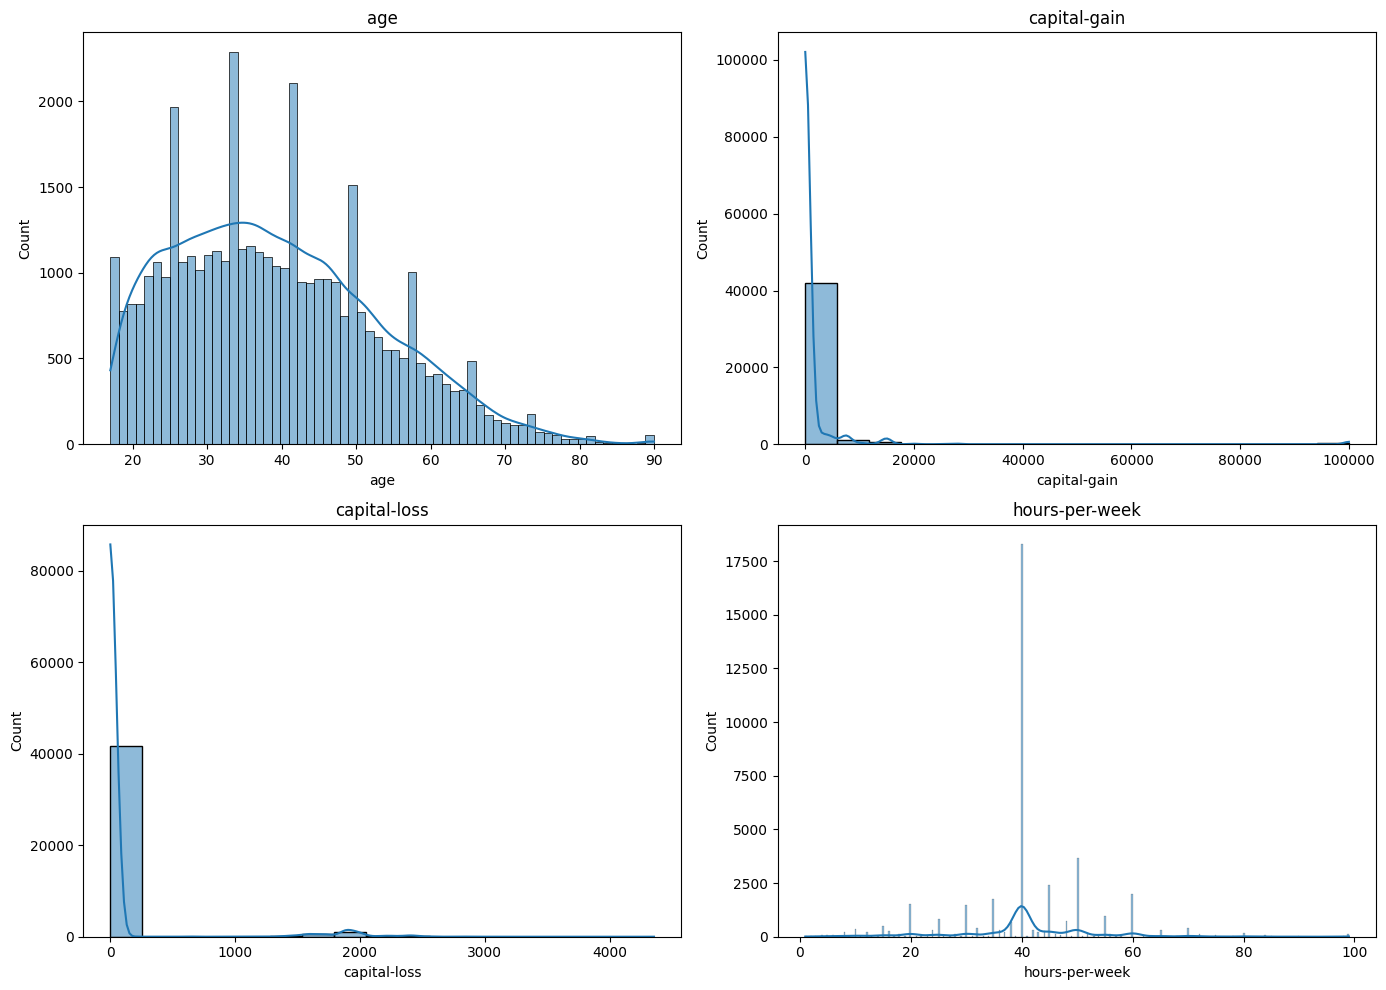

In [33]:
# after handling outliers:
# continous numerical cols
plt.figure(figsize = (14, 10))
i = 1
for column in continuous_cols:
  plt.subplot(2, 2, i)
  sns.histplot(df_adult[column], kde=True)
  plt.title(column)
  i += 1
plt.tight_layout()
plt.show()

In [34]:
# imputing NaN in the 2 continuous numerical cols with -> median, due to skewed distribution
df_adult['age'] = df_adult['age'].fillna(df_adult['age'].median())
df_adult['hours-per-week'] = df_adult['hours-per-week'].fillna(df_adult['hours-per-week'].median())

# imputing NaN in the 3 categorical cols with -> mode
df_adult['workclass'] = df_adult['workclass'].fillna(df_adult['workclass'].mode()[0])
df_adult['occupation'] = df_adult['occupation'].fillna(df_adult['occupation'].mode()[0])
df_adult['native-country'] = df_adult['native-country'].fillna(df_adult['native-country'].mode()[0])

In [35]:
# after missing value imputation

df_adult.isna().sum()

,0
age,0
workclass,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0
capital-gain,0
capital-loss,0


# Splitting

In [36]:
df_adult['income'].value_counts()     # checking class imbalance

,count
income,
<=50K,33220
>50K,10774


In [37]:
# Splitting feature cols and target col
X = df_adult.drop(columns=target_col)
y = df_adult[target_col]

# TrainTestSplit
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,
                                                    stratify=y)        # because the target column is moderately imbalanced
                                                                       # recommeded for classification problems

# Encoding

## Label encoding for binary variables

In [38]:
# Can't use the same Labelencoder() obj for multiple columns after train_test_split
  # Because LabelEncoder remembers the mapping it learned during fit(), while trfansform() it uses the mapping learnt earlier

In [39]:
le_sex = LabelEncoder()

X_train["sex"] = le_sex.fit_transform(X_train["sex"])
X_test["sex"] = le_sex.transform(X_test["sex"])

In [40]:
le_target = LabelEncoder()

y_train = le_target.fit_transform(y_train)
y_test = le_target.transform(y_test)

## OHE for feature columns

In [41]:
# creating obj
ohe = OneHotEncoder(
    drop="first",               # dropping 1st col of after ohe encoded cols
    sparse_output=False,
    handle_unknown="ignore"
)

In [42]:
# Encoding seperately on train and test

encoded_train = ohe.fit_transform(X_train[nominal_cols])
encoded_test = ohe.transform(X_test[nominal_cols])

In [43]:
# Converting the encoded data into DataFrames

encoded_train = pd.DataFrame(
    encoded_train,
    columns = ohe.get_feature_names_out(nominal_cols),
    index=X_train.index
)

encoded_test = pd.DataFrame(
    encoded_test,
    columns = ohe.get_feature_names_out(nominal_cols),
    index=X_test.index
)

In [44]:
# Drop original categorical columns and concatenate

X_train = X_train.drop(columns=nominal_cols)
X_test = X_test.drop(columns=nominal_cols)

X_train = pd.concat([X_train, encoded_train], axis=1)
X_test = pd.concat([X_test, encoded_test], axis=1)

# Scaling

In [45]:
# creating obj
scaler = StandardScaler()

# Also scaling 'education' as NNs generally perform better when numeric inputs are on similar scales
  # and scaling doesn't change the order, not magnitude
scale_cols = continuous_cols + discrete_cols

In [46]:
# Scaling seperately on train and test

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

# Verification after Preprocessing

In [47]:
X_train.head()


,age,education-num,sex,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
14821,1.183661,1.482051,0,1.657477,-0.229554,-0.048625,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4317,0.064727,1.102695,1,-0.152053,-0.229554,-0.449691,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2878,-0.606633,-2.311516,1,-0.152053,-0.229554,-0.048625,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
41884,-0.084464,0.343981,1,-0.152053,-0.229554,0.753508,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
102,0.586896,1.482051,0,-0.152053,-0.229554,0.753508,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [48]:
X_test.head()

,age,education-num,sex,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
12591,1.258257,-0.035376,1,-0.152053,-0.229554,0.753508,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
15070,0.661492,1.102695,1,-0.152053,-0.229554,-0.449691,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
71,-0.606633,1.102695,0,-0.152053,-0.229554,-0.048625,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
903,-0.905015,0.723338,1,-0.152053,-0.229554,-0.048625,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
10003,0.736088,1.482051,1,-0.152053,-0.229554,2.357775,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [49]:
y_train

array([1, 0, 0, ..., 0, 0, 0])

In [50]:
y_test

array([1, 1, 0, ..., 0, 1, 0])

# Sequential ANN Modelling

## Using TensorFlow

In [51]:
# model building

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),  # Input shape changed because OHE encoding changes the feature count.
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [52]:
# compile model

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [53]:
# starting time counter, fitting and training model, stopping time counter

start_time = time.perf_counter()

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

end_time = time.perf_counter()

Epoch 1/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8392 - loss: 0.3399 - val_accuracy: 0.8473 - val_loss: 0.3247
Epoch 2/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8498 - loss: 0.3179 - val_accuracy: 0.8481 - val_loss: 0.3222
Epoch 3/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8515 - loss: 0.3141 - val_accuracy: 0.8504 - val_loss: 0.3197
Epoch 4/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8533 - loss: 0.3112 - val_accuracy: 0.8466 - val_loss: 0.3214
Epoch 5/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8544 - loss: 0.3094 - val_accuracy: 0.8446 - val_loss: 0.3238
Epoch 6/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8563 - loss: 0.3066 - val_accuracy: 0.8490 - val_loss: 0.3225
Epoch 7/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8575 - loss: 0.3041 - val_accuracy: 0.8513 - val_loss: 0.3199
Epoch 8/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8570 - loss: 0.3022 - val_accuracy: 0.

In [54]:
# Printing training time of TensorFlow ANN

print(f"Training Time: {end_time - start_time:.4f} seconds")

Training Time: 137.5089 seconds


In [55]:
# Evaluation

loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8460 - loss: 0.3793
Accuracy: 0.8460052013397217


## Using PyTorch

In [56]:
# Convert to Tensors

X_train_tensor = torch.FloatTensor(X_train.values)    # since X_train and X_test are now pd DataFrames rather than NumPy arrays.
X_test_tensor = torch.FloatTensor(X_test.values)          # Use .values to take only values and discard the header of the df

y_train_tensor = torch.FloatTensor(y_train.reshape(-1, 1))
y_test_tensor = torch.FloatTensor(y_test.reshape(-1, 1))

In [57]:
# building model

class ANN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(X_train.shape[1], 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

In [58]:
# create model as an object of Class ANN

model = ANN()

In [59]:
# Loss Function
# creating an object of the BinaryCrossentropyLoss Class from the nn module, to use its loss function

criterion = nn.BCELoss()

In [60]:
# Optimizer
# Calling function 'Adam' from package 'optim' from nn module

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [61]:
# # starting time counter, compiling, fitting & training model, stopping time counter

start_time = time.perf_counter()

epochs = 50

for epoch in range(epochs):
  outputs = model(X_train_tensor)
  loss = criterion(outputs, y_train_tensor)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if (epoch + 1) % 10 == 0:
      print(f"Epoch {epoch + 1}", f"Loss = {loss.item():.4f}")

end_time = time.perf_counter()

Epoch 10 Loss = 0.6396
Epoch 20 Loss = 0.6033
Epoch 30 Loss = 0.5426
Epoch 40 Loss = 0.4641
Epoch 50 Loss = 0.3995


In [62]:
# Evaluation

with torch.no_grad():
    y_pred = model(X_test_tensor)
    y_pred = (y_pred >= 0.5).float()                        # Added thresholding (>= 0.5) before computing accuracy
    accuracy = (y_pred == y_test_tensor).float().mean()         # because the model outputs probabilities

print(f"Accuracy: {accuracy.item():.4f}")

Accuracy: 0.8254


In [63]:
# Printing training time of PyTorch ANN

print(f"Training Time: {end_time - start_time:.4f} seconds")

Training Time: 2.3646 seconds
